In [35]:
import pandas as pd
import numpy as np

# 1. Load the data [cite: 109]
df = pd.read_csv("../data/ethiopia.csv")

# 2. Add a Country column [cite: 110]
df["Country"] = "Ethiopia"

# 3. Convert YEAR and DOY to a real Date
# %Y%j is the computer code for "Year" and "Day of Year"
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

#4. Extract Month for later [cite: 112]
df['Month'] = df['Date'].dt.month

# Look at the first 5 rows to make sure it worked
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [36]:
# Replace NASA's missing value marker (-999) with "Not a Number" (NaN) [cite: 114]
df = df.replace(-999, np.nan)

# Check for duplicate rows [cite: 116]
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

# Drop them if there are any [cite: 116]
df = df.drop_duplicates()

# Get a quick summary of the numbers [cite: 117]
df.describe()

Number of duplicate rows found: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [37]:
# Count missing values per column [cite: 118]
missing_counts = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

# Put them in a nice table
missing_report = pd.DataFrame({'Missing Count': missing_counts, 'Percentage (%)': missing_percent})
print(missing_report)

             Missing Count  Percentage (%)
YEAR                     0             0.0
DOY                      0             0.0
T2M                      0             0.0
T2M_MAX                  0             0.0
T2M_MIN                  0             0.0
T2M_RANGE                0             0.0
PRECTOTCORR              0             0.0
RH2M                     0             0.0
WS2M                     0             0.0
WS2M_MAX                 0             0.0
PS                       0             0.0
QV2M                     0             0.0
Country                  0             0.0
Date                     0             0.0
Month                    0             0.0


In [38]:
from scipy import stats
import numpy as np
import pandas as pd

# 0. Ensure dataframe is loaded
if 'df' not in globals():
    df = pd.read_csv("../data/ethiopia.csv")
    df["Country"] = "Ethiopia"
    df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
    df["Month"] = df["Date"].dt.month
    df = df.replace(-999, np.nan)

# 1. Define the columns we want to track for weird values
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# 2. Calculate Z-scores
# we use np.abs to turn negative scores into positive ones
z_scores = np.abs(stats.zscore(df[cols_to_check], nan_policy='omit'))

# 3. Find rows where any column has a Z-score > 3
outliers = (z_scores > 3).any(axis=1)
print(f"Number of outliers rows detected: {outliers.sum()}")

# 4. Show a few outliers to see if they look like errors or just extreme weather
df[outliers].head()


Number of outliers rows detected: 132


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
144,2015,145,18.45,24.94,14.15,10.79,29.07,68.37,1.52,3.07,77.06,11.33,Ethiopia,2015-05-25,5
145,2015,146,17.60,23.52,13.22,10.30,34.38,75.91,1.66,3.53,77.07,11.89,Ethiopia,2015-05-26,5
177,2015,178,15.79,19.03,13.33,5.70,23.89,83.89,1.81,3.03,77.18,12.09,Ethiopia,2015-06-27,6
214,2015,215,15.97,21.06,12.58,8.48,23.46,84.73,1.58,2.55,77.04,12.32,Ethiopia,2015-08-03,8
556,2016,192,15.20,18.00,12.89,5.11,25.19,85.47,1.33,2.99,77.07,11.95,Ethiopia,2016-07-10,7


In [39]:
# 1. Fill the small missing gaps (Nans)
# 'ffill' stands for 'forward fill' - it carries the last known value forward
df_clean = df.ffill()

# 2. Check if we missing anything
remaining_nulls = df_clean.isna().sum().sum()
print(f"Total missing values remaining: {remaining_nulls}")

# 3. Save this 'Gold Standard' data to your computer 
# We will use this cleaned file for all our charts and Task 3
df_clean.to_csv("../data/ethiopia_clean.csv", index=False)
print("Note: Cleaned data exported to data/ethiopia_clean.csv")

Total missing values remaining: 0
Note: Cleaned data exported to data/ethiopia_clean.csv


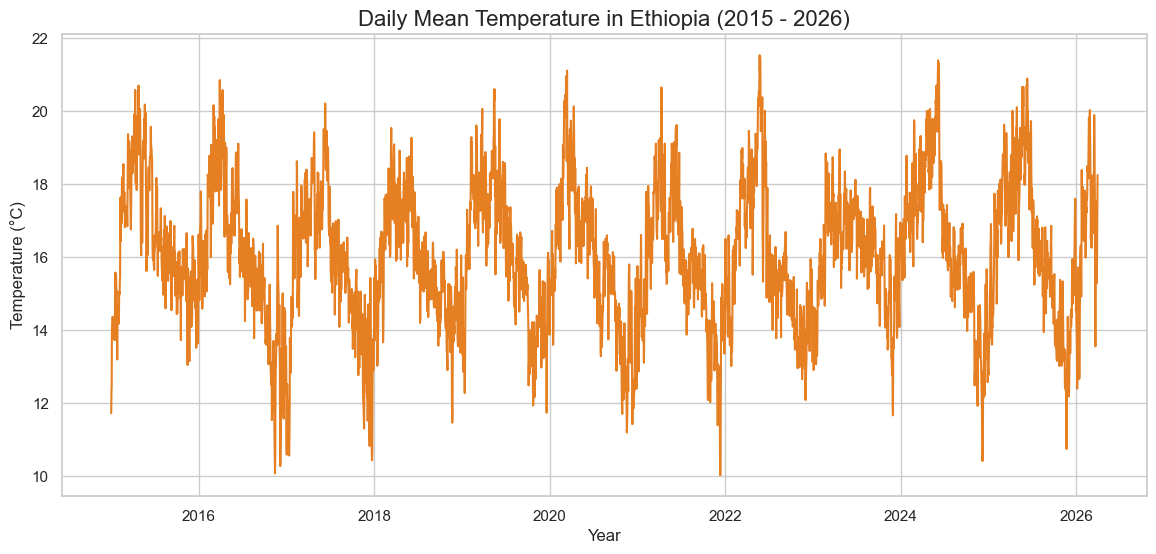

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a Line Plot for Temperature
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_clean, x='Date', y='T2M', color='#e67e22')

plt.title('Daily Mean Temperature in Ethiopia (2015 - 2026)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.show()


Observation: The temperature shows a clear seasonal cycle, with peaks occurring consistently each year.

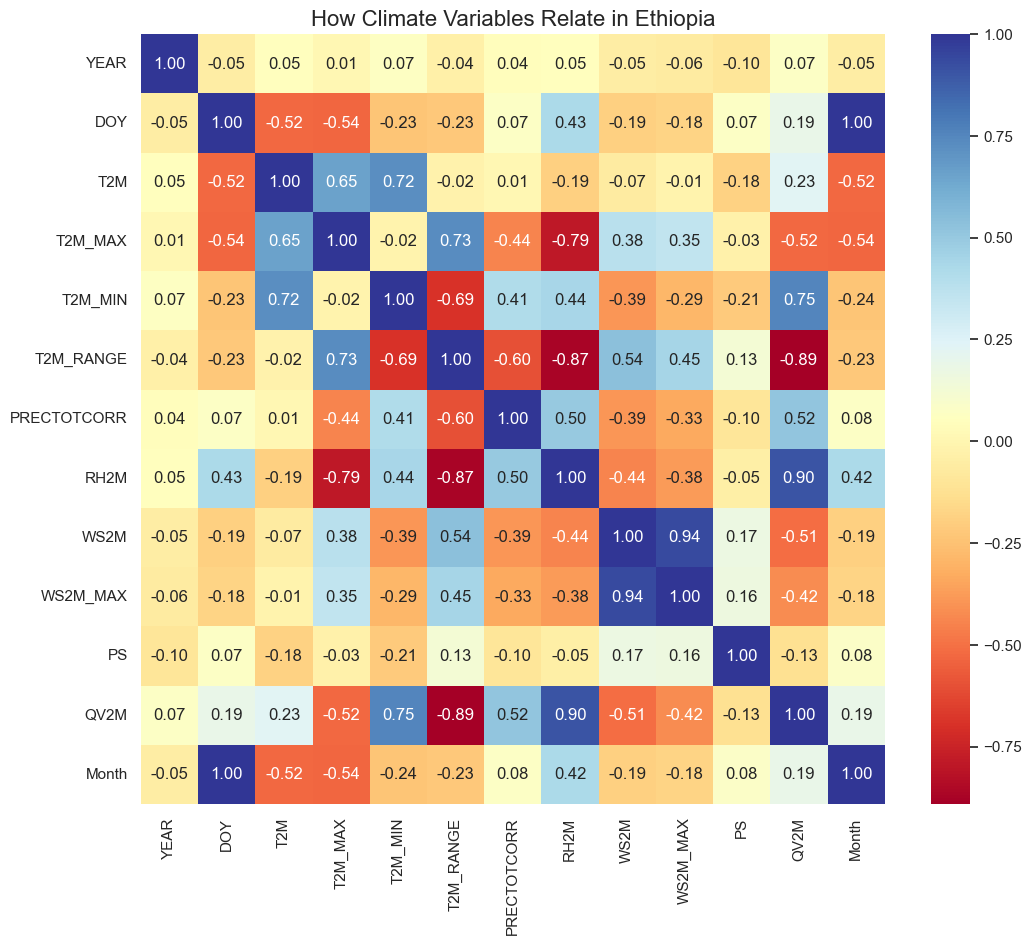

In [41]:
# 1. We only want to correlate numbers, not dates or text
numeric_cols = df_clean.select_dtypes(include=[np.number])

# 2. Create the Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_cols.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu', fmt=".2f")
plt.title('How Climate Variables Relate in Ethiopia', fontsize=16)
plt.show()

I noticed a strong negative correlation between Temperature (T2M) and Relative Humidity (RH2M), meaning as it gets hotter, the air usually becomes drier.

C:\Users\Guyatu\AppData\Local\Temp\ipykernel_61420\852684259.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x='Month', y='PRECTOTCORR', palette='Blues_d', ci=None)
C:\Users\Guyatu\AppData\Local\Temp\ipykernel_61420\852684259.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Month', y='PRECTOTCORR', palette='Blues_d', ci=None)


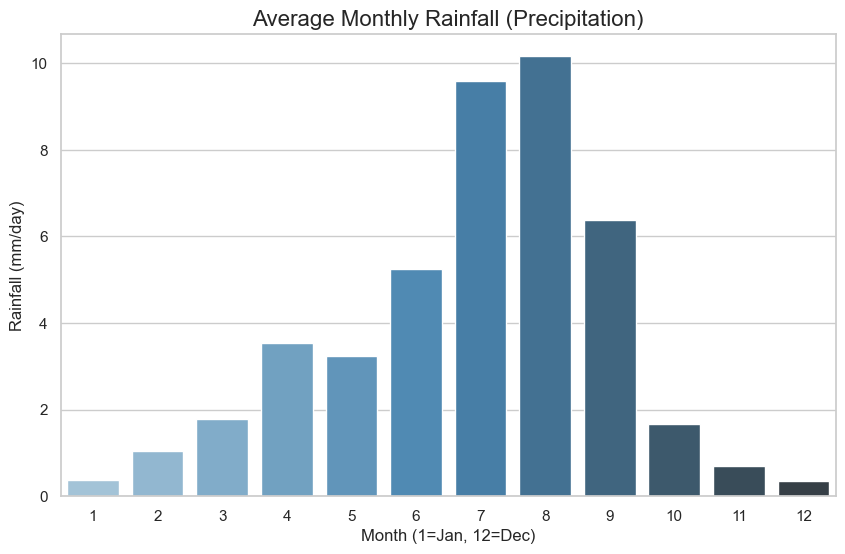

In [45]:
plt.figure(figsize=(10, 6))

# We group by Month and calculate the average rainfall
sns.barplot(data=df_clean, x='Month', y='PRECTOTCORR', palette='Blues_d', ci=None)

plt.title('Average Monthly Rainfall (Precipitation)', fontsize=16)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Rainfall (mm/day)', fontsize=12)
plt.show()

The bar chart clearly shows the 'Kiremt' (main rainy season) peaks around July and August.

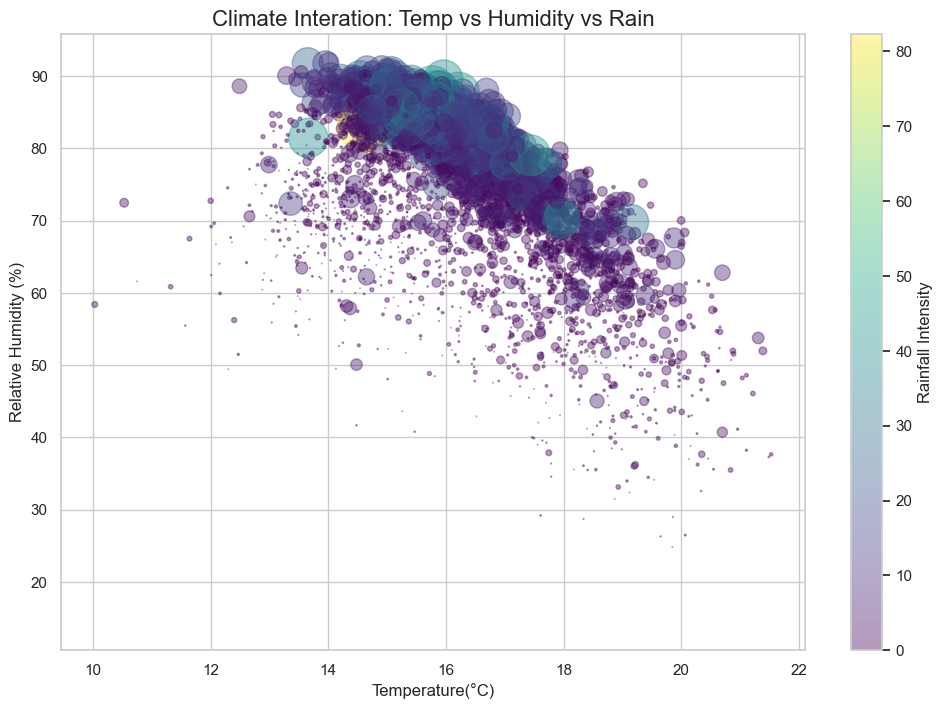

In [44]:
plt.figure(figsize=(12, 8))

# Size of bubbles is based on rainfall (multiplied by 20 so they are visible)
plt.scatter(df_clean['T2M'], df_clean['RH2M'],
            s=df_clean['PRECTOTCORR']*20,
            alpha=0.4, c=df_clean['PRECTOTCORR'], cmap='viridis')

plt.colorbar(label='Rainfall Intensity')
plt.title('Climate Interation: Temp vs Humidity vs Rain', fontsize=16)
plt.xlabel('Temperature(°C)', fontsize=12)
plt.ylabel('Relative Humidity (%)', fontsize=12)
plt.show()